# UNKNOWN vs Forced Prediction — Comparison

Compares `results_mit_unknown/master_predictions.csv` vs `results_ohne_unknown/master_predictions.csv`.

Key questions:
- Does removing UNKNOWN improve accuracy?
- Or does it just replace UNKNOWN with wrong values?
- Which attributes benefit most / least from forced prediction?

## 1. Setup

In [2]:
import sys
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib64/python3.12/site-packages')
sys.path.insert(0, '/home/ma/ma_ma/ma_mpandya/RAG_Data_Cleaning/PyDI/venv/lib/python3.12/site-packages')

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from sentence_transformers import CrossEncoder
import warnings
warnings.filterwarnings('ignore')

HF_CACHE = '/home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub'
NUMERIC_ATTRIBUTES = {'read_speed_mb_s','write_speed_mb_s','height_mm','width_mm'}
FIGURES_DIR = 'figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

CONFIGS = [
    'llm_prediction',
    'rag_minilm_prediction',
    'rag_minilm_reranker_prediction',
    'rag_bge_reranker_prediction',
    'rag_te_reranker_prediction',
]
CONFIG_LABELS = {
    'llm_prediction':                 'LLM-only',
    'rag_minilm_prediction':          'RAG-MiniLM',
    'rag_minilm_reranker_prediction': 'MiniLM+RR',
    'rag_bge_reranker_prediction':    'BGE+RR',
    'rag_te_reranker_prediction':     'TE+RR',
}

# Colors
NAVY='#1E3A5F'; TEAL='#0891B2'; GREEN='#059669'; GREY='#64748B'
RED='#DC2626'; GOLD='#D97706'; GREYL='#E2E8F0'; GREYC='#F8FAFC'

# Load CrossEncoder
CE_SNAP = glob.glob(f'{HF_CACHE}/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/*/')
CE_PATH = CE_SNAP[0].rstrip('/') if CE_SNAP else 'cross-encoder/ms-marco-MiniLM-L-6-v2'
cross_encoder = CrossEncoder(CE_PATH)
print(f'CrossEncoder: {CE_PATH}')

# Load both CSVs
mit    = pd.read_csv('results_mit_UNKNOWN/master_predictions.csv')
ohne   = pd.read_csv('results_ohne_UNKNOWN/master_predictions.csv')
print(f'MIT    (with UNKNOWN):    {len(mit)} tasks')
print(f'OHNE   (forced predict):  {len(ohne)} tasks')

CrossEncoder: /home/ma/ma_ma/ma_mpandya/.cache/huggingface/hub/models--cross-encoder--ms-marco-MiniLM-L-6-v2/snapshots/c5ee24cb16019beea0893ab7796b1df96625c6b8
MIT    (with UNKNOWN):    96 tasks
OHNE   (forced predict):  96 tasks


## 2. Evaluation Functions

In [3]:
def fix_prediction(pred):
    if isinstance(pred, str) and pred.strip().upper().startswith('VALUE:'):
        val = pred.strip().split(':',1)[1].strip()
        return 'UNKNOWN' if val.upper() in {'UNKNOWN','NONE','NULL','NAN',''} else val
    return pred

def is_unknown(pred):
    return str(pred).strip().lower() in {'unknown','nan','none','null',''}

def is_correct_standard(predicted, ground_truth, attribute):
    if is_unknown(predicted): return False
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(',','').strip())
            g = float(str(ground_truth).replace(',','').strip())
            return p == g  # exact match
        except: return False
    p, g = str(predicted).lower().strip(), str(ground_truth).lower().strip()
    return p == g or p in g or g in p

def evaluate_ce(predicted, ground_truth, attribute):
    if is_unknown(predicted): return 'wrong'
    if attribute in NUMERIC_ATTRIBUTES:
        try:
            p = float(str(predicted).replace(',','').strip())
            g = float(str(ground_truth).replace(',','').strip())
            if g == 0: return 'correct' if p == 0 else 'wrong'
            r = abs(p-g)/abs(g)
            return 'correct' if r == 0.0 else ('acceptable' if r <= 0.10 else 'wrong')
        except: return 'wrong'
    score = cross_encoder.predict([[ground_truth, predicted]])[0]
    return 'correct' if score > 2.0 else ('acceptable' if score > -1.0 else 'wrong')

def compute_summary(df, label):
    """Compute accuracy summary for all configs in a dataframe."""
    rows = []
    avail = [c for c in CONFIGS if c in df.columns]
    for col in avail:
        d = df.dropna(subset=[col]).copy()
        d[col] = d[col].apply(fix_prediction)
        std  = d.apply(lambda r: is_correct_standard(r[col], r['ground_truth'], r['attribute']), axis=1).mean()
        ce   = d.apply(lambda r: evaluate_ce(r[col], r['ground_truth'], r['attribute']), axis=1).isin(['correct','acceptable']).mean()
        unk  = d[col].apply(is_unknown).mean()
        rows.append({'version': label, 'config': CONFIG_LABELS[col], 'col': col,
                     'std': std*100, 'ce': ce*100, 'unknown': unk*100, 'n': len(d)})
    return pd.DataFrame(rows)

sum_mit  = compute_summary(mit,  'With UNKNOWN')
sum_ohne = compute_summary(ohne, 'Forced Prediction')
combined = pd.concat([sum_mit, sum_ohne], ignore_index=True)

print('\nWith UNKNOWN:')
print(sum_mit[['config','std','ce','unknown']].round(1).to_string(index=False))
print('\nForced Prediction (ohne UNKNOWN):')
print(sum_ohne[['config','std','ce','unknown']].round(1).to_string(index=False))


With UNKNOWN:
    config  std   ce  unknown
  LLM-only 15.6 19.8     44.8
RAG-MiniLM 36.5 43.8     17.7
 MiniLM+RR 68.8 76.0      8.3
    BGE+RR 72.9 78.1      3.1
     TE+RR 71.9 83.3      2.1

Forced Prediction (ohne UNKNOWN):
    config  std   ce  unknown
  LLM-only 13.5 25.0     35.4
RAG-MiniLM 37.5 51.0      6.2
 MiniLM+RR 66.7 77.1      6.2
    BGE+RR 69.8 79.2      2.1
     TE+RR 70.8 81.2      2.1


## 3. Overall Comparison — Standard Accuracy

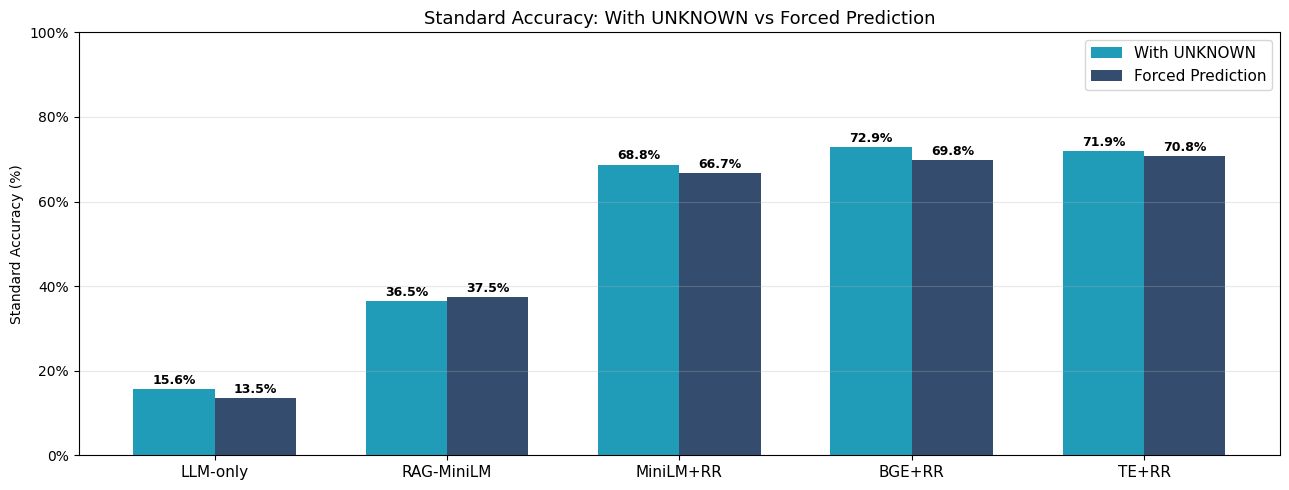

✓ compare_std.png


In [4]:
configs = sum_mit['config'].tolist()
x = np.arange(len(configs)); w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x-w/2, sum_mit['std'],  w, color=TEAL,  alpha=0.9, label='With UNKNOWN')
b2 = ax.bar(x+w/2, sum_ohne['std'], w, color=NAVY,  alpha=0.9, label='Forced Prediction')

for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=11)
ax.set_ylabel('Standard Accuracy (%)'); ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('Standard Accuracy: With UNKNOWN vs Forced Prediction', fontsize=13)
ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/compare_std.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ compare_std.png')

## 4. UNKNOWN Rate Comparison

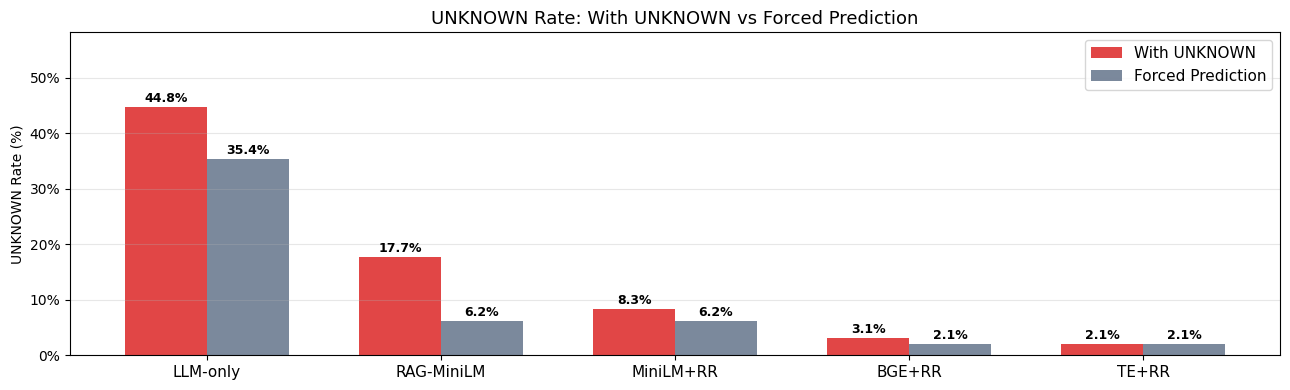

✓ compare_unknown.png


In [5]:
fig, ax = plt.subplots(figsize=(13, 4))
b1 = ax.bar(x-w/2, sum_mit['unknown'],  w, color=RED,  alpha=0.85, label='With UNKNOWN')
b2 = ax.bar(x+w/2, sum_ohne['unknown'], w, color=GREY, alpha=0.85, label='Forced Prediction')

for bar in list(b1)+list(b2):
    if bar.get_height() > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(configs, fontsize=11)
ax.set_ylabel('UNKNOWN Rate (%)'); ax.set_ylim(0, max(sum_mit['unknown'].max(), 5)*1.3)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title('UNKNOWN Rate: With UNKNOWN vs Forced Prediction', fontsize=13)
ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/compare_unknown.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ compare_unknown.png')

## 5. What Happened to the UNKNOWN Cases?

For each config — of the tasks that returned UNKNOWN in `mit_unknown`, what did `ohne_unknown` predict? Did they become correct or wrong?

In [6]:
print('=== What happened to UNKNOWN cases? ===')
print(f'\n{"Config":<25} {"Was UNKNOWN":>12} {"→ Correct":>12} {"→ Wrong":>12} {"Precision":>10}')
print('-'*72)

for col in [c for c in CONFIGS if c in mit.columns and c in ohne.columns]:
    label = CONFIG_LABELS[col]

    m = mit.copy();   m[col] = m[col].apply(fix_prediction)
    o = ohne.copy();  o[col] = o[col].apply(fix_prediction)

    # Tasks that were UNKNOWN in mit
    was_unknown = m[m[col].apply(is_unknown)][['df1_idx','attribute','ground_truth']].copy()
    if len(was_unknown) == 0:
        print(f'  {label:<23} {0:>12} — no UNKNOWNs')
        continue

    # What did ohne predict for those same tasks?
    merged = was_unknown.merge(
        o[['df1_idx','attribute', col]],
        on=['df1_idx','attribute'], how='left'
    )
    merged['forced_pred'] = merged[col].apply(fix_prediction)
    merged['correct'] = merged.apply(
        lambda r: is_correct_standard(r['forced_pred'], r['ground_truth'], r['attribute']), axis=1)

    n_unk     = len(merged)
    n_correct = merged['correct'].sum()
    n_wrong   = n_unk - n_correct
    precision = n_correct/n_unk*100 if n_unk > 0 else 0

    print(f'  {label:<23} {n_unk:>12} {n_correct:>12} {n_wrong:>12} {precision:>9.1f}%')

print('\nPrecision = fraction of forced predictions that were correct')

=== What happened to UNKNOWN cases? ===

Config                     Was UNKNOWN    → Correct      → Wrong  Precision
------------------------------------------------------------------------
  LLM-only                          43            2           41       4.7%
  RAG-MiniLM                        17            2           15      11.8%
  MiniLM+RR                          8            0            8       0.0%
  BGE+RR                             3            1            2      33.3%
  TE+RR                              2            1            1      50.0%

Precision = fraction of forced predictions that were correct


## 6. Per-Attribute Breakdown — Numeric vs Text

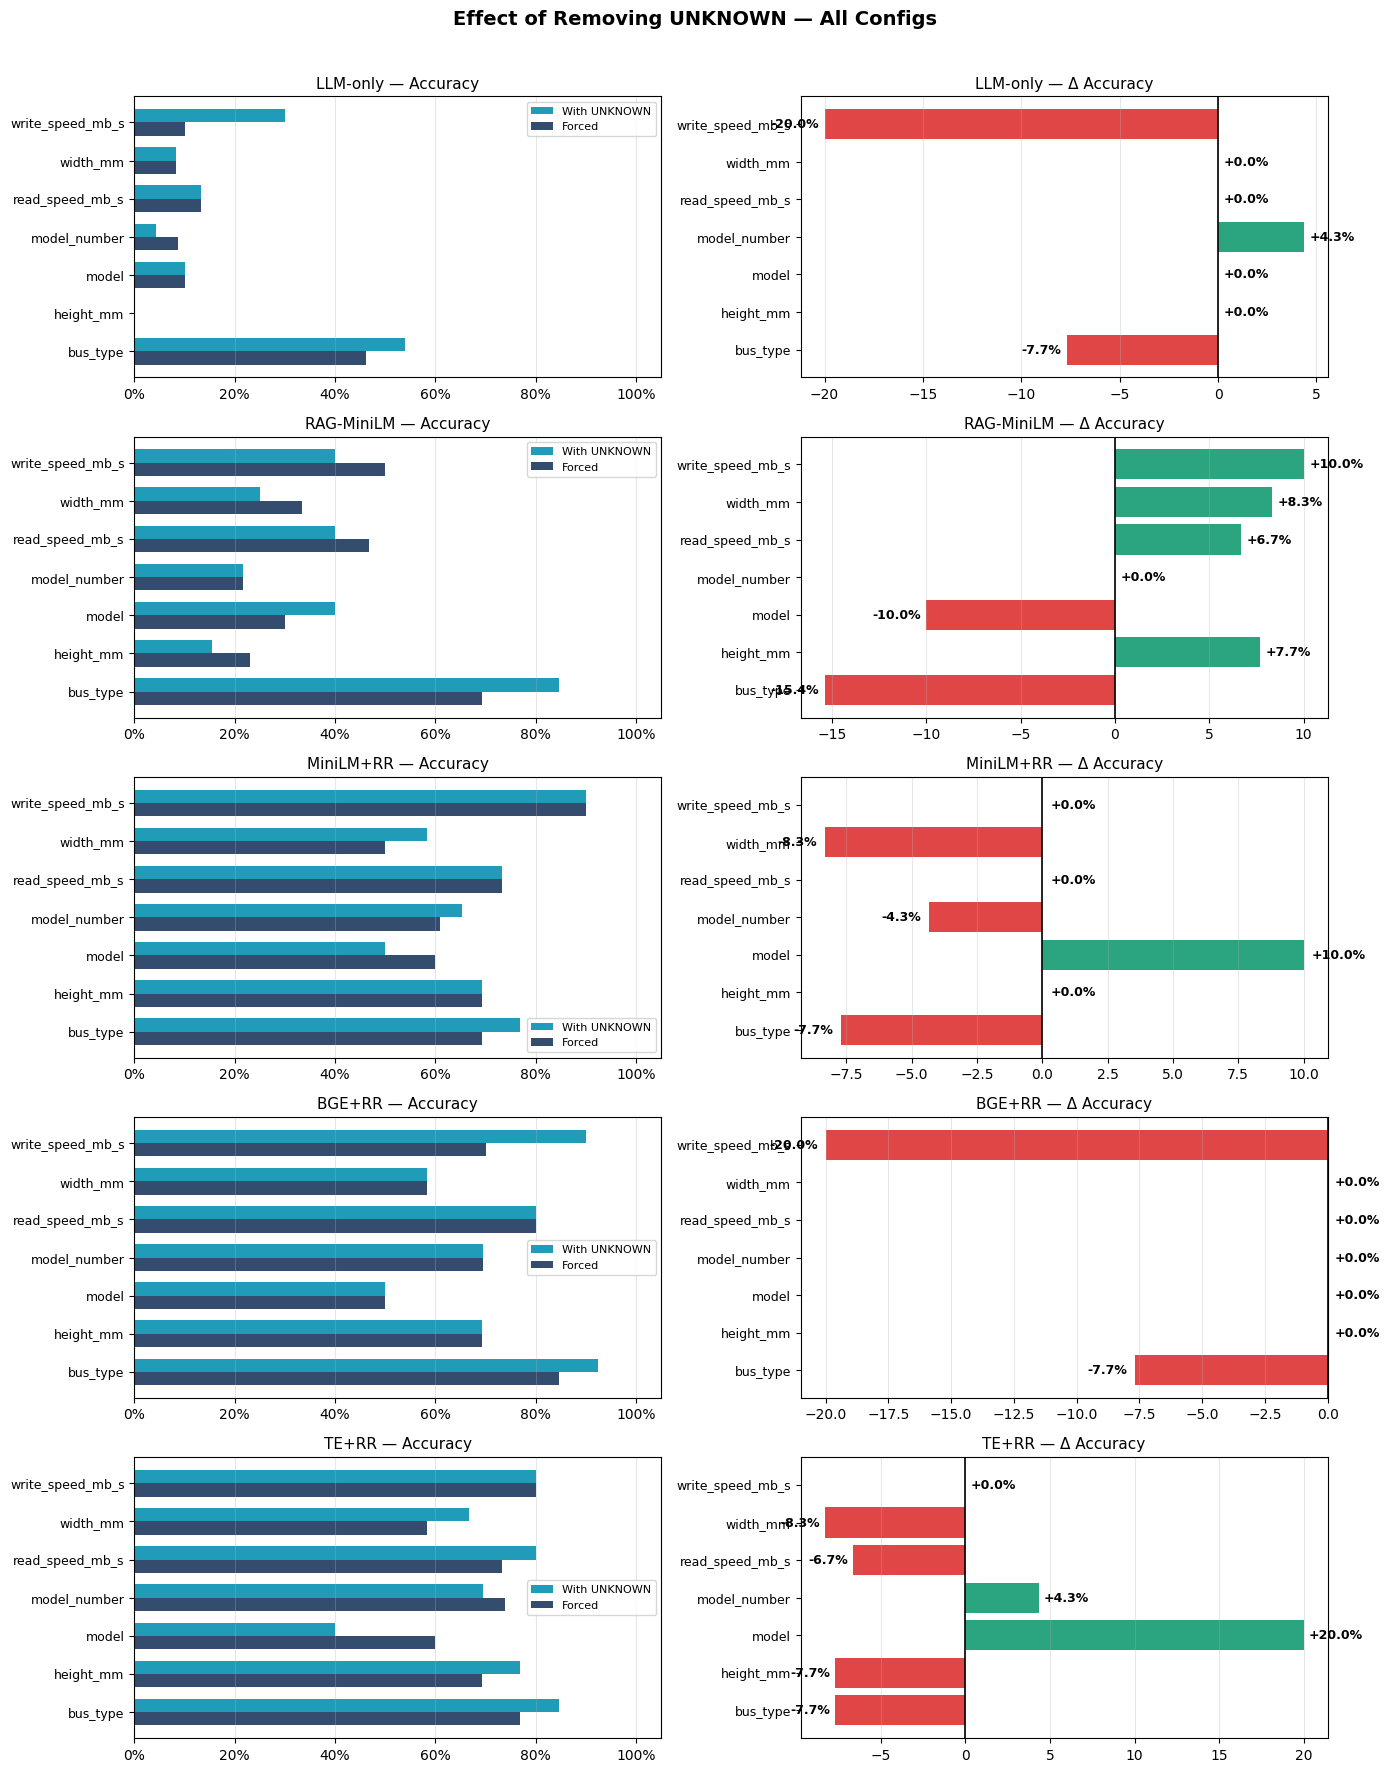

✓ compare_per_attr_all.png


In [11]:
fig, axes = plt.subplots(len(CONFIGS), 2, figsize=(14, len(CONFIGS)*3.5))

for row_i, col in enumerate([c for c in CONFIGS if c in mit.columns]):
    label = CONFIG_LABELS[col]
    pa_mit  = per_attr_summary(mit,  col).rename(columns={'std':'std_mit','unknown':'unk_mit'})
    pa_ohne = per_attr_summary(ohne, col).rename(columns={'std':'std_ohne','unknown':'unk_ohne'})
    pa = pa_mit.merge(pa_ohne, on='attribute')
    pa['std_diff'] = pa['std_ohne'] - pa['std_mit']
    attrs = pa['attribute'].tolist()
    y = np.arange(len(attrs)); bh = 0.35

    # Left: accuracy
    ax = axes[row_i][0]
    ax.barh(y+bh/2, pa['std_mit'],  bh, color=TEAL, alpha=0.9, label='With UNKNOWN')
    ax.barh(y-bh/2, pa['std_ohne'], bh, color=NAVY, alpha=0.9, label='Forced')
    ax.set_yticks(y); ax.set_yticklabels(attrs, fontsize=9)
    ax.set_title(f'{label} — Accuracy', fontsize=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 105); ax.grid(axis='x', alpha=0.3); ax.legend(fontsize=8)

    # Right: delta
    ax = axes[row_i][1]
    colors = [GREEN if v >= 0 else RED for v in pa['std_diff']]
    ax.barh(y, pa['std_diff'], color=colors, alpha=0.85)
    for i, v in enumerate(pa['std_diff']):
        ax.text(v+(0.3 if v>=0 else -0.3), i, f'{v:+.1f}%',
                va='center', ha='left' if v>=0 else 'right', fontsize=9, fontweight='bold')
    ax.set_yticks(y); ax.set_yticklabels(attrs, fontsize=9)
    ax.set_title(f'{label} — Δ Accuracy', fontsize=11)
    ax.axvline(0, color='black', lw=1.2); ax.grid(axis='x', alpha=0.3)

plt.suptitle('Effect of Removing UNKNOWN — All Configs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/compare_per_attr_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ compare_per_attr_all.png')

## 7. Visualisation — Per-Attribute Change (LLM-only)

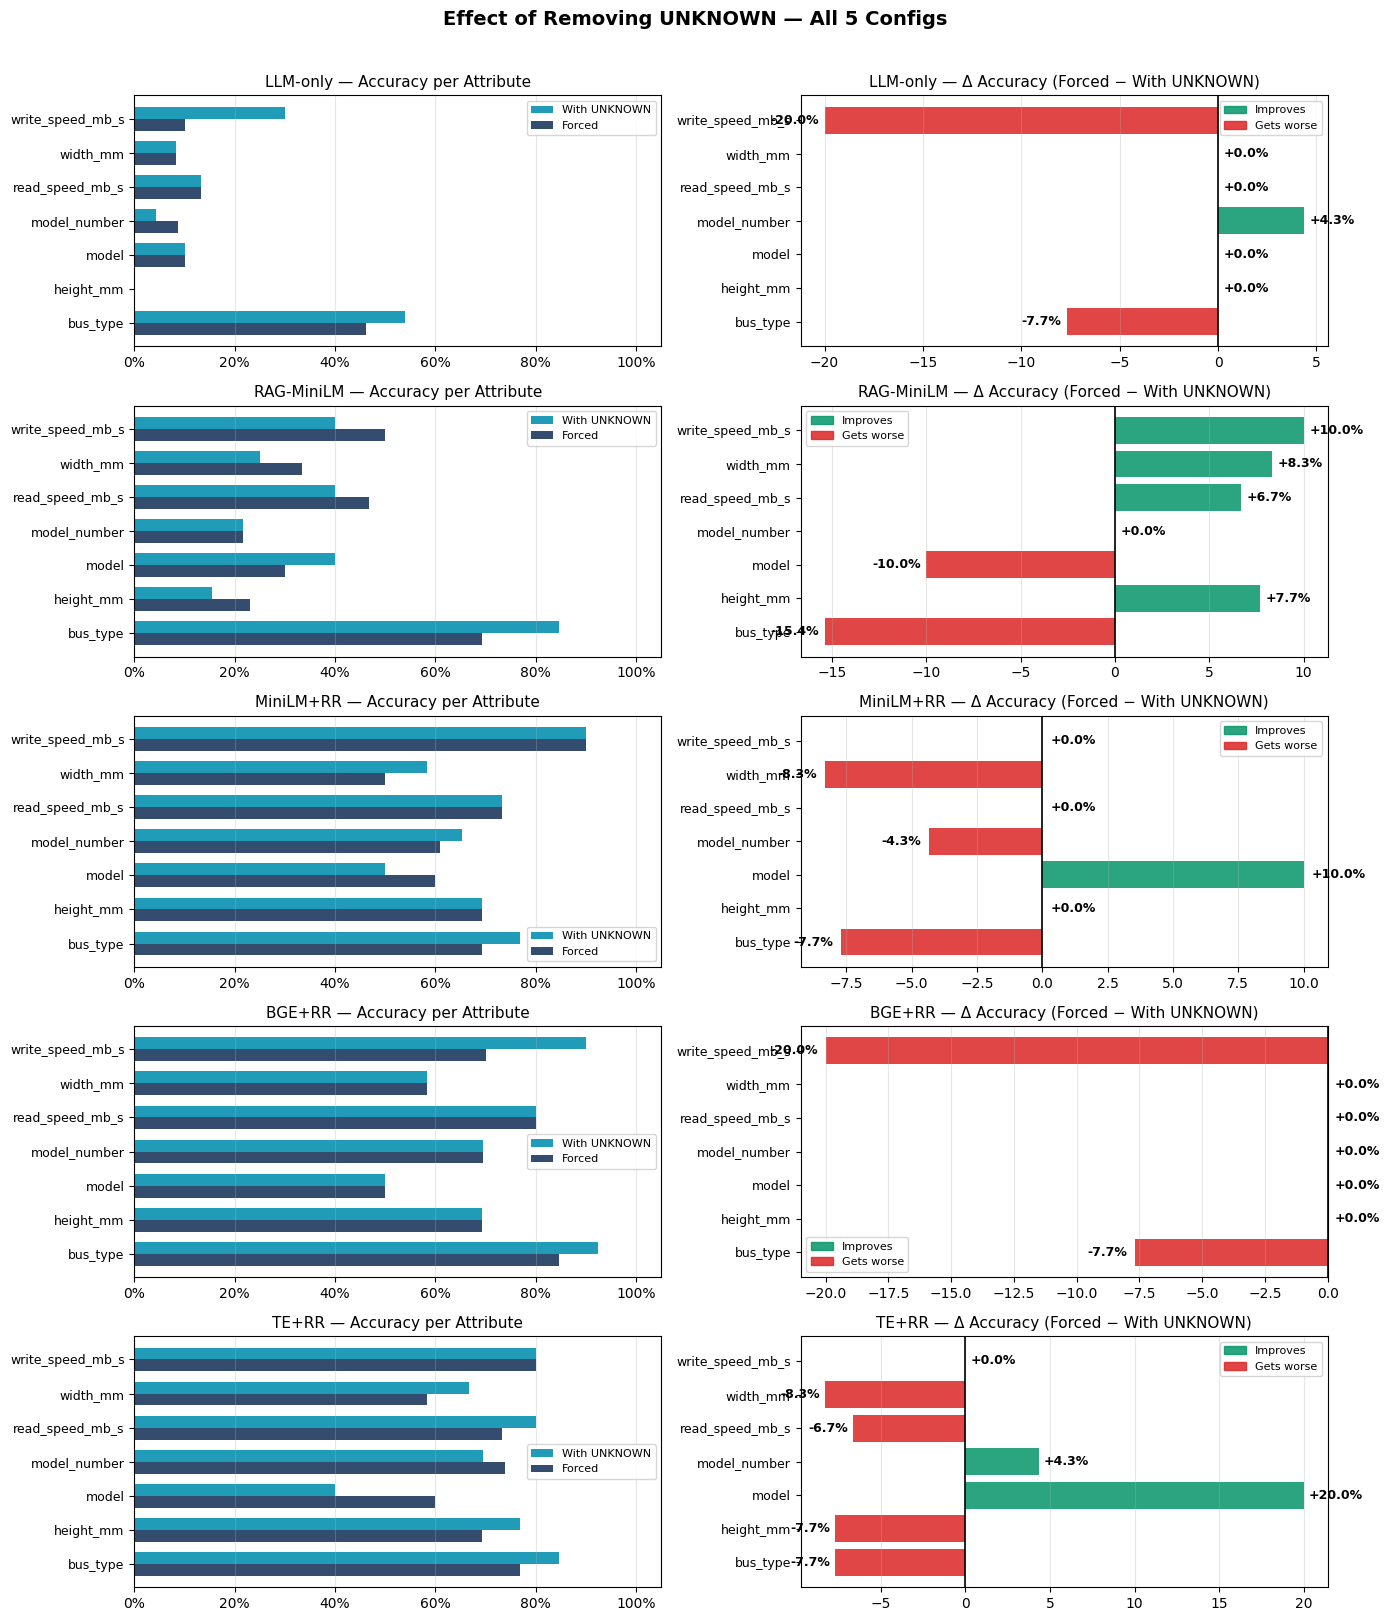

✓ compare_per_attr_all.png


In [13]:
avail_configs = [c for c in CONFIGS if c in mit.columns]
fig, axes = plt.subplots(len(avail_configs), 2, figsize=(14, len(avail_configs)*3.2))

for row_i, col in enumerate(avail_configs):
    label = CONFIG_LABELS[col]
    pa_mit  = per_attr_summary(mit,  col).rename(columns={'std':'std_mit','unknown':'unk_mit'})
    pa_ohne = per_attr_summary(ohne, col).rename(columns={'std':'std_ohne','unknown':'unk_ohne'})
    pa = pa_mit.merge(pa_ohne, on='attribute')
    pa['std_diff'] = pa['std_ohne'] - pa['std_mit']
    attrs = pa['attribute'].tolist()
    y = np.arange(len(attrs)); bh = 0.35

    # Left: accuracy comparison
    ax = axes[row_i][0]
    ax.barh(y+bh/2, pa['std_mit'],  bh, color=TEAL, alpha=0.9, label='With UNKNOWN')
    ax.barh(y-bh/2, pa['std_ohne'], bh, color=NAVY, alpha=0.9, label='Forced')
    ax.set_yticks(y); ax.set_yticklabels(attrs, fontsize=9)
    ax.set_title(f'{label} — Accuracy per Attribute', fontsize=11)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlim(0, 105); ax.grid(axis='x', alpha=0.3); ax.legend(fontsize=8)

    # Right: delta
    ax = axes[row_i][1]
    bar_colors = [GREEN if v >= 0 else RED for v in pa['std_diff']]
    ax.barh(y, pa['std_diff'], color=bar_colors, alpha=0.85)
    for i, v in enumerate(pa['std_diff']):
        ax.text(v+(0.3 if v>=0 else -0.3), i, f'{v:+.1f}%',
                va='center', ha='left' if v>=0 else 'right',
                fontsize=9, fontweight='bold')
    ax.set_yticks(y); ax.set_yticklabels(attrs, fontsize=9)
    ax.set_title(f'{label} — Δ Accuracy (Forced − With UNKNOWN)', fontsize=11)
    ax.axvline(0, color='black', lw=1.2); ax.grid(axis='x', alpha=0.3)
    greenp = mpatches.Patch(color=GREEN, alpha=0.85, label='Improves')
    redp   = mpatches.Patch(color=RED,   alpha=0.85, label='Gets worse')
    ax.legend(handles=[greenp, redp], fontsize=8)

plt.suptitle('Effect of Removing UNKNOWN — All 5 Configs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/compare_per_attr_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ compare_per_attr_all.png')

## 8. Key Finding — What Replaced UNKNOWN

In [14]:
for col in [c for c in CONFIGS if c in mit.columns]:
    label = CONFIG_LABELS[col]
    m = mit.copy();  m[col] = m[col].apply(fix_prediction)
    o = ohne.copy(); o[col] = o[col].apply(fix_prediction)

    was_unk = m[m[col].apply(is_unknown)][['df1_idx','attribute','ground_truth']].copy()
    if len(was_unk) == 0:
        print(f'\n--- {label}: No UNKNOWNs ---'); continue

    merged = was_unk.merge(o[['df1_idx','attribute',col]], on=['df1_idx','attribute'], how='left')
    merged['forced']  = merged[col].apply(fix_prediction)
    merged['correct'] = merged.apply(
        lambda r: is_correct_standard(r['forced'], r['ground_truth'], r['attribute']), axis=1)
    merged['is_numeric'] = merged['attribute'].isin(NUMERIC_ATTRIBUTES)

    n_correct = merged['correct'].sum()
    precision = n_correct/len(merged)*100

    print(f'\n--- {label}: {len(merged)} UNKNOWNs → {n_correct} correct ({precision:.1f}% precision) ---')
    print(f'{"Row":<6} {"Attribute":<22} {"Ground Truth":<20} {"Forced Pred":<25} {"✓/✗"}')
    print('='*80)
    for _, r in merged.sort_values(['is_numeric','attribute']).iterrows():
        sym = '✓' if r['correct'] else '✗'
        print(f'{int(r["df1_idx"]):<6} {r["attribute"]:<22} {str(r["ground_truth"]):<20} {str(r["forced"]):<25} {sym}')


--- LLM-only: 43 UNKNOWNs → 2 correct (4.7% precision) ---
Row    Attribute              Ground Truth         Forced Pred               ✓/✗
5      bus_type               PCIe 3.0 x16         PCIe                      ✓
54     bus_type               PCIe 3.0 x16         PCIe 3.0 x16              ✓
0      model_number           GV-N3080GAMING OC-10GD NVIDIA GeForce RTX 3080 Gaming OC ✗
9      model_number           V375-040R            GTX 1660 TI               ✗
15     model_number           100-506008           RADEON PRO WX 4100        ✗
16     model_number           NE6166SS18J9-161F    Palit GeForce GTX 1660 SUPER 6GB StormX Boost Graphics Card ✗
30     model_number           WDBMCG5000ABT-WESN   WDBF1T0040BBL             ✗
54     model_number           N20702-08D6-1710VA23 GV-N2070IX2-8GD           ✗
9      height_mm              46.0                 UNKNOWN                   ✗
18     height_mm              7.0                  UNKNOWN                   ✗
28     height_mm         

## 9. Summary Table

In [15]:
print('='*70)
print('FINAL COMPARISON SUMMARY')
print('='*70)

merge_sum = sum_mit[['config','std','ce','unknown']].merge(
    sum_ohne[['config','std','ce','unknown']],
    on='config', suffixes=('_mit','_ohne')
)
merge_sum['Δ std'] = merge_sum['std_ohne'] - merge_sum['std_mit']
merge_sum['Δ ce']  = merge_sum['ce_ohne']  - merge_sum['ce_mit']

print(f'\n{"Config":<25} {"Std(mit)":>9} {"Std(ohne)":>10} {"Δ Std":>7} {"UNK(mit)":>9} {"UNK(ohne)":>10}')
print('-'*73)
for _,r in merge_sum.iterrows():
    print(f'  {r["config"]:<23} {r["std_mit"]:>8.1f}% {r["std_ohne"]:>9.1f}% '
          f'{r["Δ std"]:>+6.1f}% {r["unknown_mit"]:>8.1f}% {r["unknown_ohne"]:>9.1f}%')

print(f'\nKey insight:')
llm = merge_sum[merge_sum['config']=='LLM-only'].iloc[0]
print(f'  LLM-only UNKNOWN dropped from {llm["unknown_mit"]:.1f}% → {llm["unknown_ohne"]:.1f}%')
print(f'  Accuracy changed by {llm["Δ std"]:+.1f}pp')
if llm['Δ std'] < 2:
    print(f'  → UNKNOWN cases were genuine knowledge gaps — forced prediction did not help')
else:
    print(f'  → Some UNKNOWN cases had useful world knowledge that was being suppressed')

merge_sum

FINAL COMPARISON SUMMARY

Config                     Std(mit)  Std(ohne)   Δ Std  UNK(mit)  UNK(ohne)
-------------------------------------------------------------------------
  LLM-only                    15.6%      13.5%   -2.1%     44.8%      35.4%
  RAG-MiniLM                  36.5%      37.5%   +1.0%     17.7%       6.2%
  MiniLM+RR                   68.8%      66.7%   -2.1%      8.3%       6.2%
  BGE+RR                      72.9%      69.8%   -3.1%      3.1%       2.1%
  TE+RR                       71.9%      70.8%   -1.0%      2.1%       2.1%

Key insight:
  LLM-only UNKNOWN dropped from 44.8% → 35.4%
  Accuracy changed by -2.1pp
  → UNKNOWN cases were genuine knowledge gaps — forced prediction did not help


,config,std_mit,ce_mit,unknown_mit,std_ohne,ce_ohne,unknown_ohne,Δ std,Δ ce
0,LLM-only,15.625000,19.791667,44.791667,13.541667,25.000000,35.416667,-2.083333,5.208333
1,RAG-MiniLM,36.458333,43.750000,17.708333,37.500000,51.041667,6.250000,1.041667,7.291667
2,MiniLM+RR,68.750000,76.041667,8.333333,66.666667,77.083333,6.250000,-2.083333,1.041667
3,BGE+RR,72.916667,78.125000,3.125000,69.791667,79.166667,2.083333,-3.125000,1.041667
4,TE+RR,71.875000,83.333333,2.083333,70.833333,81.250000,2.083333,-1.041667,-2.083333
